# Análisis Exploratorio de Datos
## Asignación Escolar en Bogotá: Calidad Académica, Demanda y Controles Socioeconómicos

**Pregunta de investigación:** ¿La calidad académica ($q_j$) explica suficientemente la demanda por colegios
($sobre\_demanda_j$), o existe varianza sistemática no explicada consistente con que los hogares
responden a señales no académicas?

**Dataset:** `data/primary/colegios_features.geojson` — 306 colegios oficiales, Bogotá D.C.

**Secciones:**
1. Descripción general del dataset
2. Distribuciones univariadas
3. Distribución geográfica de calidad y demanda
4. Calidad vs. demanda: análisis de varianza residual
5. Controles socioeconómicos y correlaciones

In [1]:
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

warnings.filterwarnings('ignore')

BASE    = Path('..').resolve()
PRIMARY = BASE / 'data' / 'primary'
FIGURES = BASE / 'reports' / 'figures' / 'eda'
FIGURES.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 150,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
    'font.family': 'serif',
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'legend.frameon': False,
    'legend.fontsize': 9,
})

C1   = '#2166ac'
C2   = '#d6604d'
C3   = '#4dac26'
GRAY = '#636363'

print('Configuración lista.')

Configuración lista.


---
## 1. Descripción General del Dataset

In [2]:
with open(PRIMARY / 'colegios_features.geojson', encoding='utf-8') as f:
    gj = json.load(f)

rows = []
for feat in gj['features']:
    row = dict(feat['properties'])
    geom = feat.get('geometry') or {}
    coords = geom.get('coordinates', [None, None])
    row['lon'] = coords[0]
    row['lat'] = coords[1]
    rows.append(row)

df = pd.DataFrame(rows)

KEY_VARS = [
    'q_j', 'sobre_demanda_j',
    'dist_transmilenio_m', 'dist_sitp_m', 'dist_parque_m',
    'ingreso_percapita_promedio', 'tasa_pobreza_monetaria', 'tasa_ipm',
    'gasto_educ_promedio', 'capacidad_pago_promedio',
    'tasa_deficit_cuantitativo', 'tasa_deficit_cualitativo',
    'homicidios', 'hurto_personas',
    'pct_no_oficial',
]
for col in KEY_VARS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Etiquetas legibles
LABELS = {
    'q_j':                        'Puntaje Saber 11 promedio ($q_j$)',
    'sobre_demanda_j':             'Razón de sobredemanda (solicitudes / matrícula)',
    'dist_transmilenio_m':         'Distancia a estación TransMilenio (m)',
    'dist_sitp_m':                 'Distancia a paradero SITP (m)',
    'dist_parque_m':               'Distancia al parque más cercano (m)',
    'ingreso_percapita_promedio':   'Ingreso per cápita promedio (COP, UPZ)',
    'tasa_pobreza_monetaria':      'Tasa de pobreza monetaria (UPZ)',
    'tasa_ipm':                    'Índice de Pobreza Multidimensional (UPZ)',
    'gasto_educ_promedio':         'Gasto mensual en educación (COP, UPZ)',
    'capacidad_pago_promedio':     'Índice de capacidad de pago (UPZ)',
    'tasa_deficit_cuantitativo':   'Tasa de déficit cuantitativo de vivienda (UPZ)',
    'tasa_deficit_cualitativo':    'Tasa de déficit cualitativo de vivienda (UPZ)',
    'homicidios':                  'Homicidios acumulados (localidad)',
    'hurto_personas':              'Hurtos a personas acumulados (localidad)',
    'pct_no_oficial':              'Competencia privada: % de sedes no oficiales (localidad)',
}

print(f'N colegios: {len(df)}')
print(f'N columnas: {len(df.columns)}')

N colegios: 366
N columnas: 54


In [3]:
# Tabla 1. Estadísticas descriptivas
desc = df[KEY_VARS].describe().T[['count','mean','std','min','50%','max']]
desc.columns = ['N', 'Media', 'DE', 'Mín.', 'Mediana', 'Máx.']
desc.index = [LABELS.get(i, i) for i in desc.index]
print('Tabla 1. Estadísticas descriptivas — variables principales')
print('=' * 95)
print(desc.round(2).to_string())

Tabla 1. Estadísticas descriptivas — variables principales
                                                              N      Media         DE       Mín.    Mediana        Máx.
Puntaje Saber 11 promedio ($q_j$)                         326.0     259.19      15.08     225.94     258.87      339.91
Razón de sobredemanda (solicitudes / matrícula)           354.0       1.12       0.12       1.03       1.10        2.78
Distancia a estación TransMilenio (m)                     366.0    1523.75    1378.16      35.57    1273.69    16738.57
Distancia a paradero SITP (m)                             366.0     158.73     388.26       4.40     103.19     4413.84
Distancia al parque más cercano (m)                       366.0     175.06     458.01       8.10     110.33     6851.96
Ingreso per cápita promedio (COP, UPZ)                    326.0  867202.22  463998.25  390100.44  765944.56  3477195.69
Tasa de pobreza monetaria (UPZ)                           326.0       0.41       0.16       0.05     

---
## 2. Distribuciones Univariadas

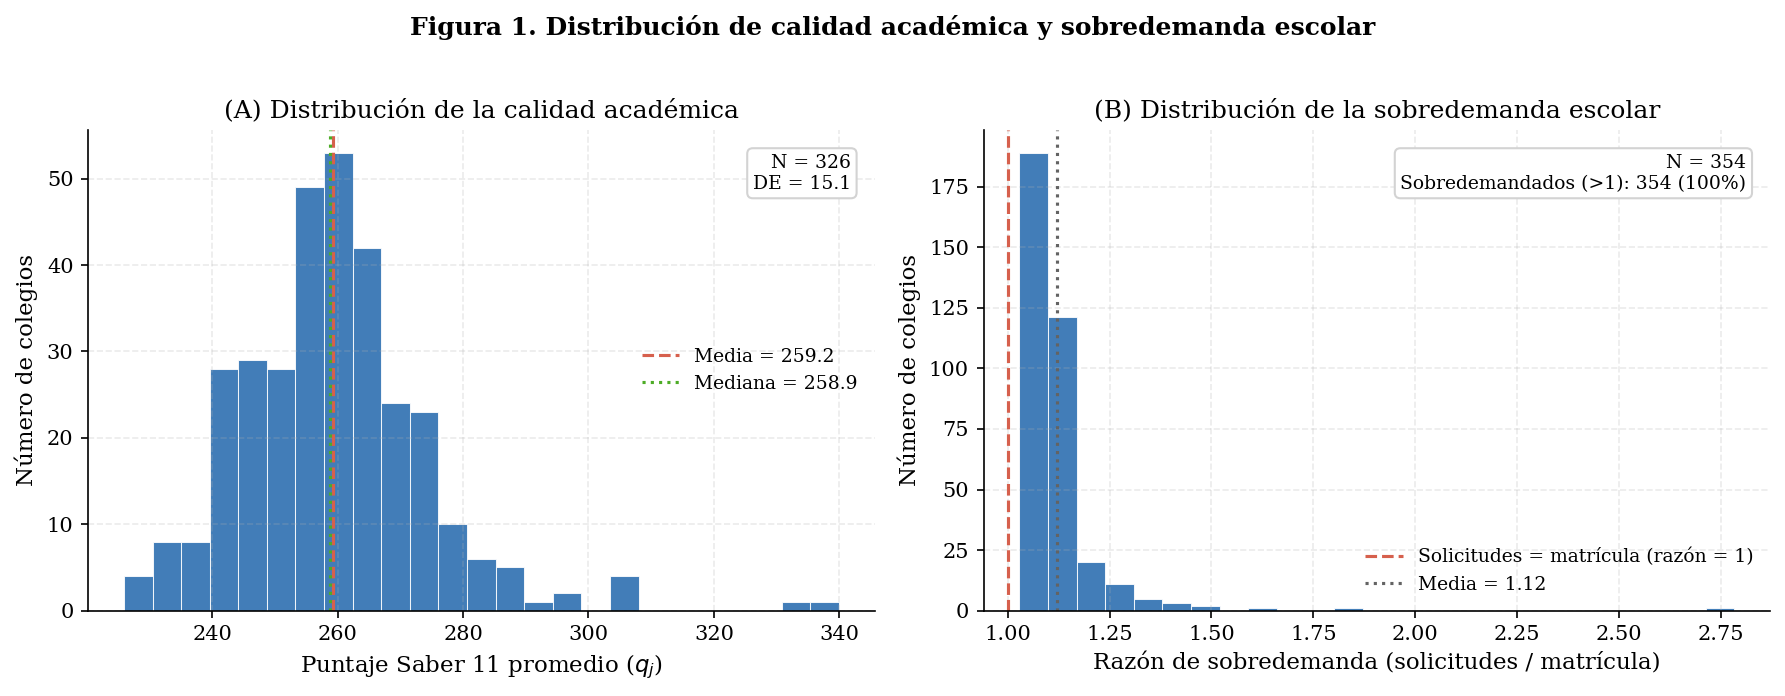

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Panel A: Calidad académica
ax = axes[0]
data_q = df['q_j'].dropna()
ax.hist(data_q, bins=25, color=C1, edgecolor='white', linewidth=0.5, alpha=0.85)
ax.axvline(data_q.mean(),   color=C2, linestyle='--', linewidth=1.5,
           label=f'Media = {data_q.mean():.1f}')
ax.axvline(data_q.median(), color=C3, linestyle=':',  linewidth=1.5,
           label=f'Mediana = {data_q.median():.1f}')
ax.set_xlabel('Puntaje Saber 11 promedio ($q_j$)')
ax.set_ylabel('Número de colegios')
ax.set_title('(A) Distribución de la calidad académica')
ax.legend()
ax.text(0.97, 0.95, f'N = {len(data_q)}\nDE = {data_q.std():.1f}',
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='lightgray'))

# Panel B: Sobredemanda
ax = axes[1]
data_sd = df['sobre_demanda_j'].dropna()
ax.hist(data_sd, bins=25, color=C1, edgecolor='white', linewidth=0.5, alpha=0.85)
ax.axvline(1.0, color=C2, linestyle='--', linewidth=1.5,
           label='Solicitudes = matrícula (razón = 1)')
ax.axvline(data_sd.mean(), color=GRAY, linestyle=':', linewidth=1.5,
           label=f'Media = {data_sd.mean():.2f}')
ax.set_xlabel('Razón de sobredemanda (solicitudes / matrícula)')
ax.set_ylabel('Número de colegios')
ax.set_title('(B) Distribución de la sobredemanda escolar')
ax.legend()
over = (data_sd > 1).sum()
ax.text(0.97, 0.95,
        f'N = {len(data_sd)}\nSobredemandados (>1): {over} ({over/len(data_sd)*100:.0f}%)',
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='lightgray'))

plt.suptitle('Figura 1. Distribución de calidad académica y sobredemanda escolar',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / '01_distribuciones_calidad_demanda.png', bbox_inches='tight')
plt.show()

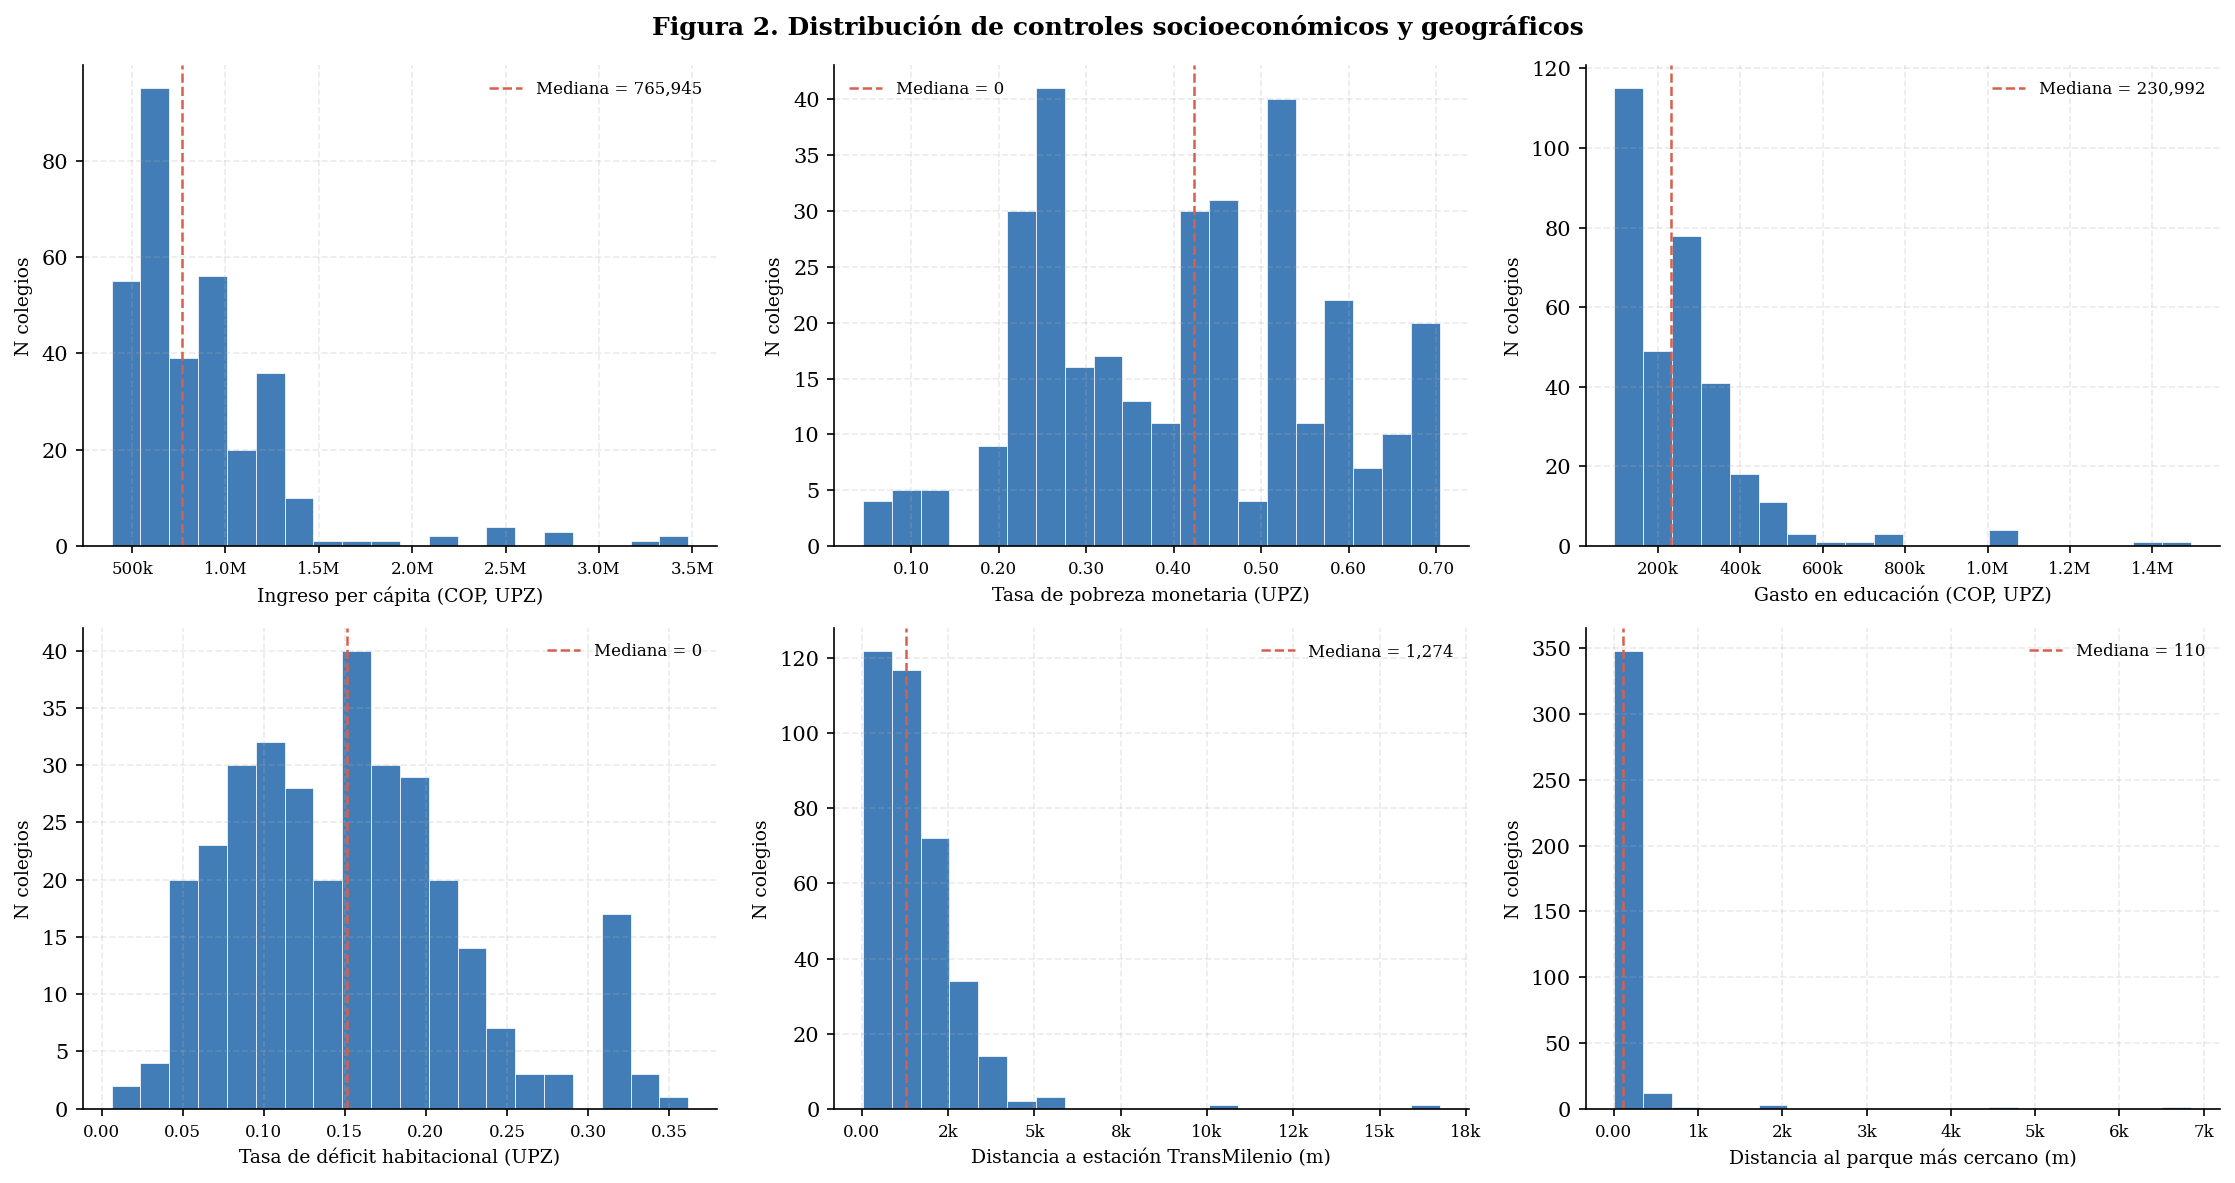

In [5]:
CONTROL_PLOT = [
    ('ingreso_percapita_promedio', 'Ingreso per cápita (COP, UPZ)'),
    ('tasa_pobreza_monetaria',     'Tasa de pobreza monetaria (UPZ)'),
    ('gasto_educ_promedio',        'Gasto en educación (COP, UPZ)'),
    ('tasa_deficit_habitacional',  'Tasa de déficit habitacional (UPZ)'),
    ('dist_transmilenio_m',        'Distancia a estación TransMilenio (m)'),
    ('dist_parque_m',              'Distancia al parque más cercano (m)'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, (col, label) in zip(axes, CONTROL_PLOT):
    data = df[col].dropna() if col in df.columns else pd.Series(dtype=float)
    if len(data) == 0:
        ax.set_visible(False)
        continue
    ax.hist(data, bins=20, color=C1, edgecolor='white', linewidth=0.4, alpha=0.85)
    ax.axvline(data.median(), color=C2, linestyle='--', linewidth=1.2,
               label=f'Mediana = {data.median():,.0f}')
    ax.set_xlabel(label, fontsize=9)
    ax.set_ylabel('N colegios', fontsize=9)
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{x/1e6:.1f}M' if abs(x) >= 1e6
        else (f'{x/1e3:.0f}k' if abs(x) >= 1000 else f'{x:.2f}')
    ))
    ax.tick_params(axis='x', labelsize=8)

plt.suptitle('Figura 2. Distribución de controles socioeconómicos y geográficos',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / '02_distribuciones_controles.png', bbox_inches='tight')
plt.show()

---
## 3. Distribución Geográfica

La concentración espacial de calidad o demanda indicaría que los controles
a nivel de UPZ y localidad son necesarios para aislar el efecto de las señales visuales.

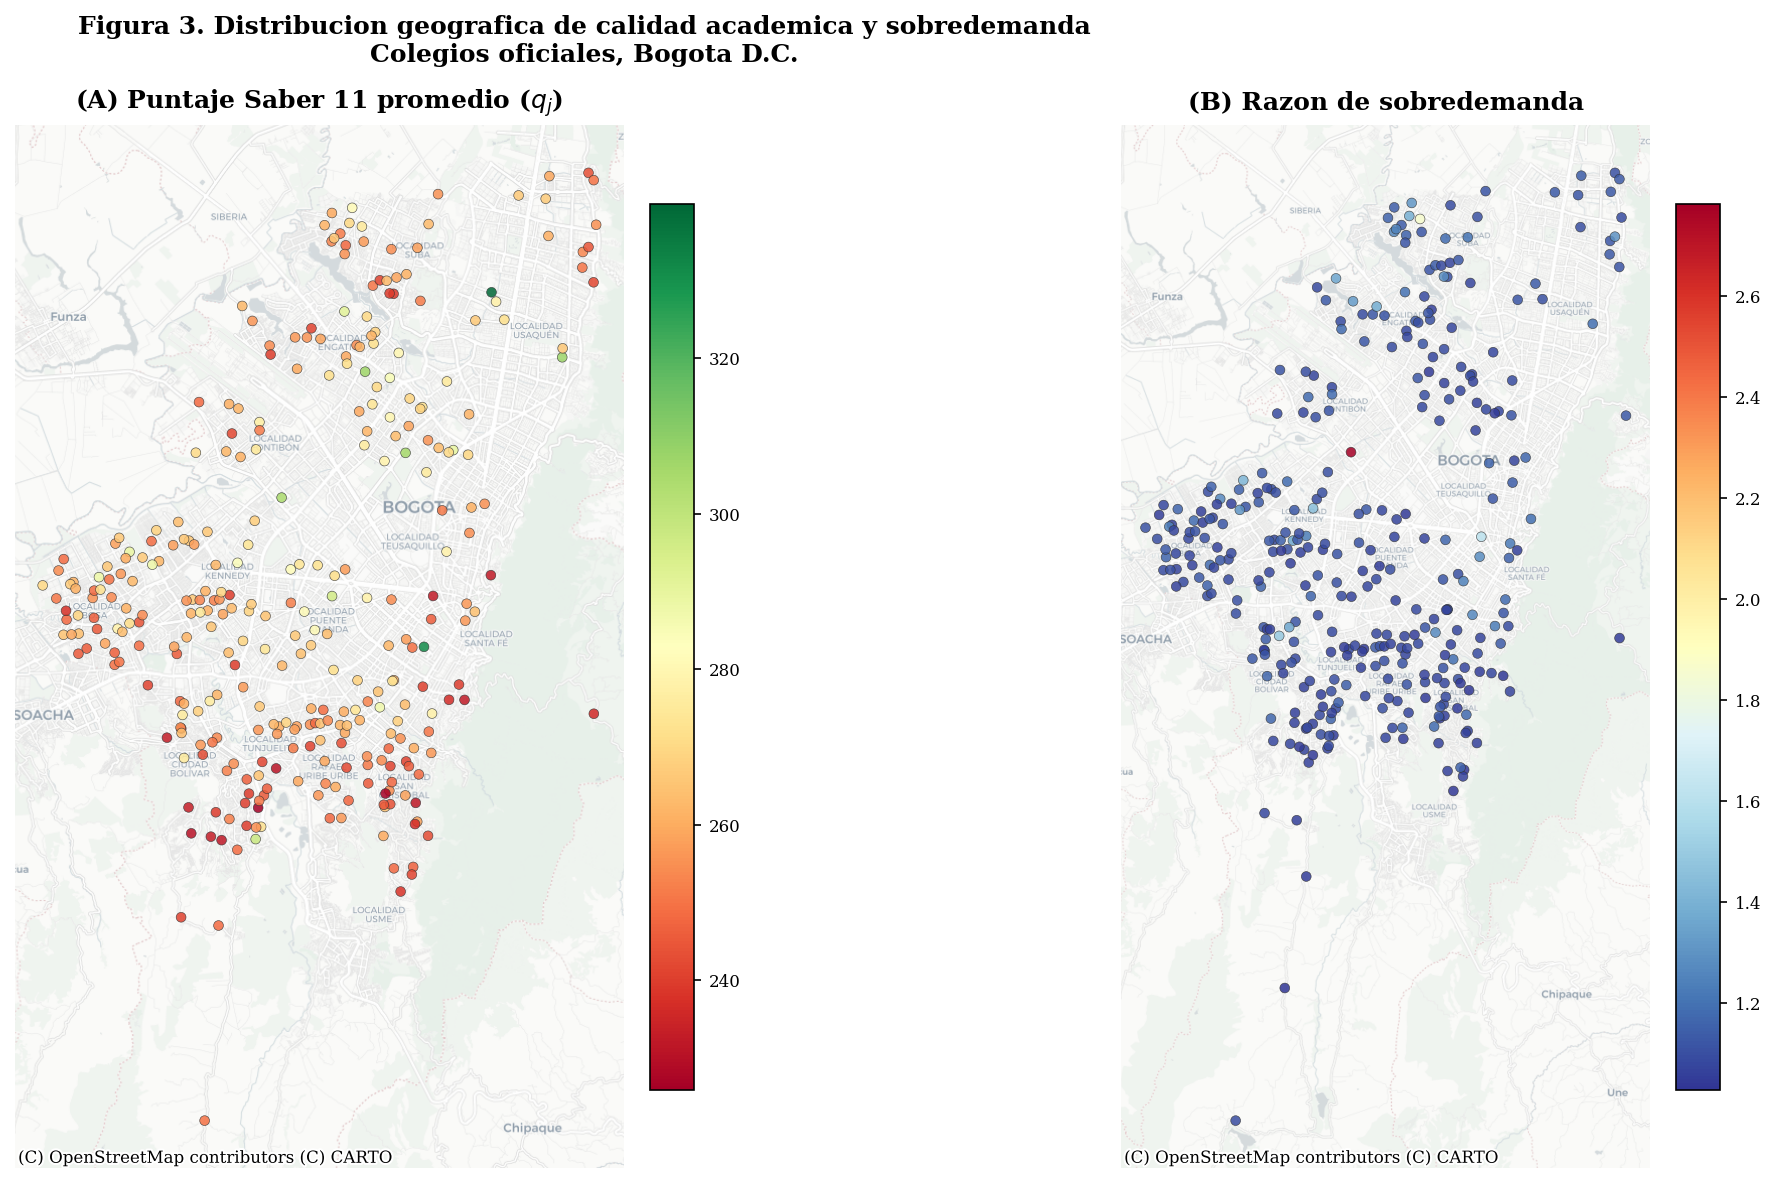

In [6]:
import geopandas as gpd
import contextily as ctx
import matplotlib.colors as mcolors

# Construir GeoDataFrame en WGS84 y reproyectar a Web Mercator (requerido por contextily)
gdf = gpd.GeoDataFrame(
    df, geometry=gpd.points_from_xy(df["lon"], df["lat"]), crs="EPSG:4326"
).to_crs(epsg=3857)

PANELS = [
    ("q_j",            "(A) Puntaje Saber 11 promedio ($q_j$)",  "RdYlGn"),
    ("sobre_demanda_j","(B) Razon de sobredemanda",               "RdYlBu_r"),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, (col, title, cmap) in zip(axes, PANELS):
    valid = gdf[gdf[col].notna()]

    valid.plot(
        column=col, cmap=cmap, ax=ax,
        markersize=22, alpha=0.85,
        edgecolors="#333", linewidths=0.3,
        legend=False, zorder=3,
    )

    # Colorbar pegada a su propio panel
    norm = mcolors.Normalize(vmin=valid[col].min(), vmax=valid[col].max())
    sm   = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cb = fig.colorbar(sm, ax=ax, fraction=0.035, pad=0.02, shrink=0.85)
    cb.ax.tick_params(labelsize=8)

    # Mapa base CartoDB Positron (fondo claro, minimalista)
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=12, zorder=1)

    ax.set_axis_off()
    ax.set_title(title, fontweight="bold", pad=8)

plt.suptitle(
    "Figura 3. Distribucion geografica de calidad academica y sobredemanda\n"
    "Colegios oficiales, Bogota D.C.",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.savefig(FIGURES / "03_mapa_calidad_demanda.png", bbox_inches="tight", dpi=200)
plt.show()


---
## 3b. Competencia del Sector Privado por Localidad

El porcentaje de sedes no oficiales (`pct_no_oficial`) captura la intensidad
competitiva del mercado educativo local. En localidades con alta oferta privada,
los hogares tienen mas alternativas y pueden responder con mayor sensibilidad
a senales no academicas al elegir colegio.


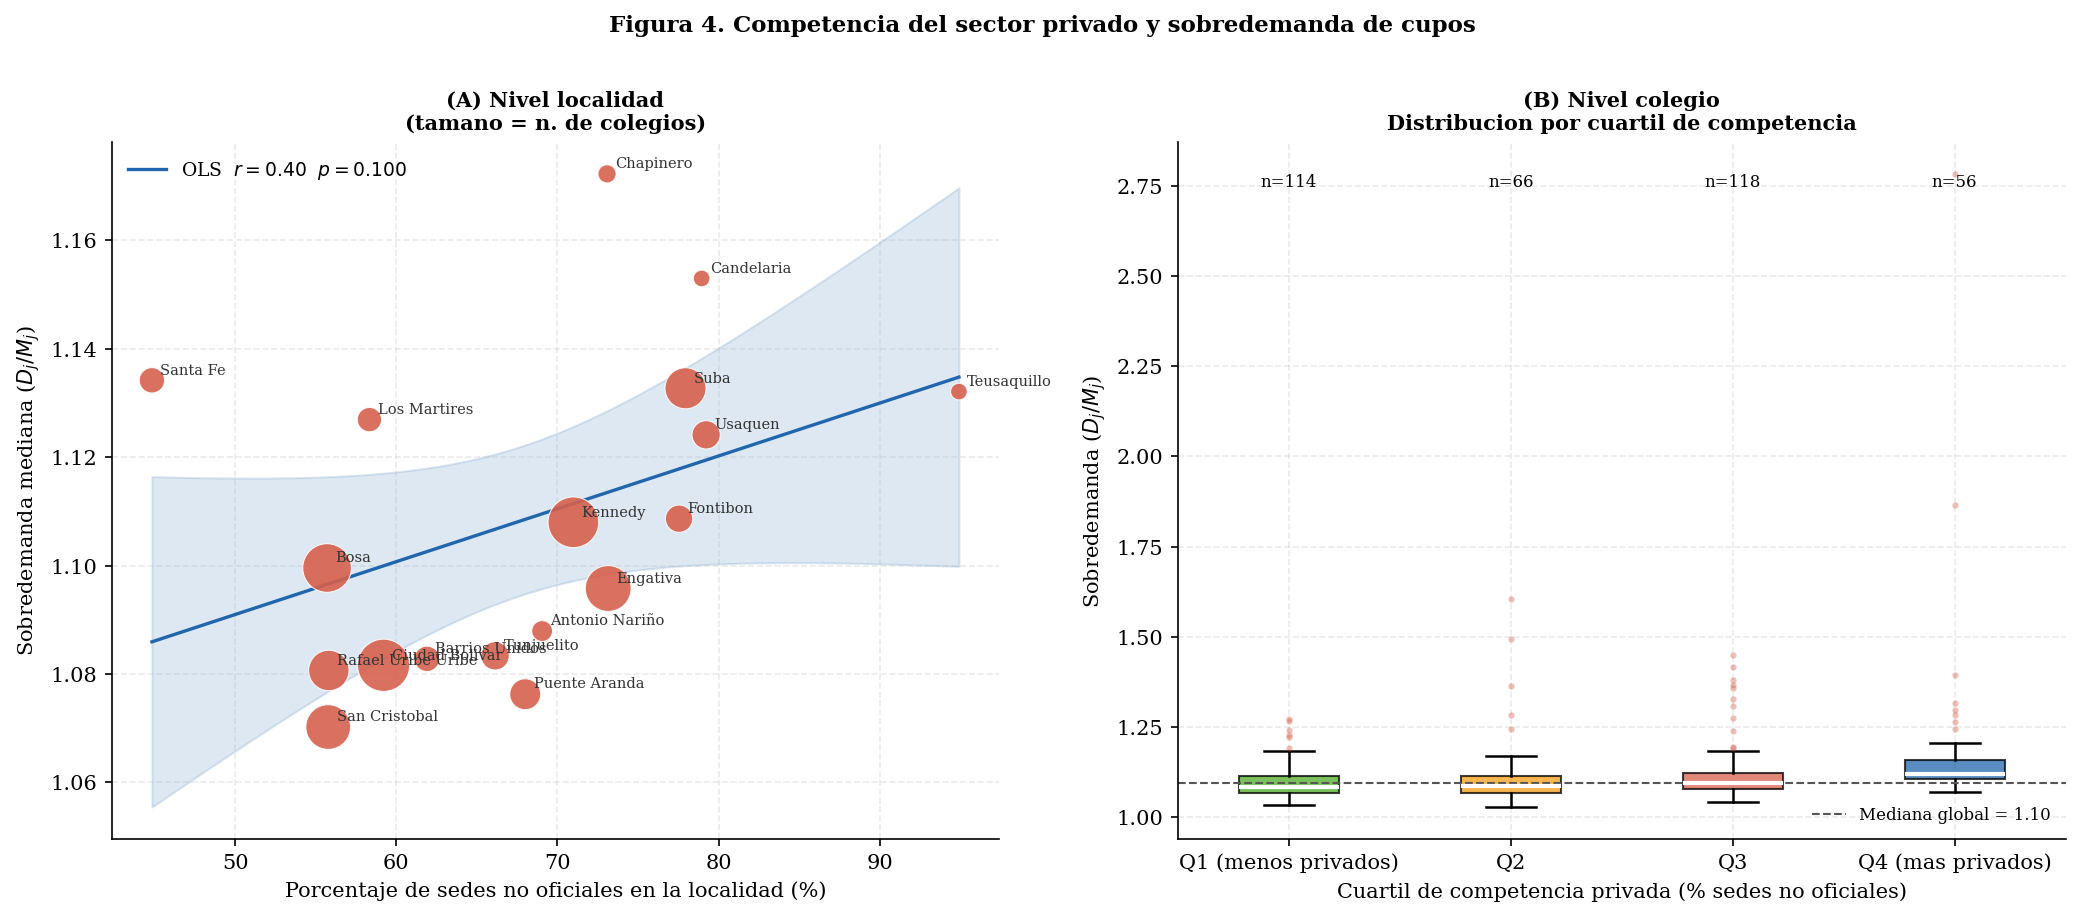

In [7]:
# Figura 4. Competencia privada y sobredemanda
from scipy import stats as sp_stats

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel A: nivel localidad
ax = axes[0]

loc_agg = (
    df[['nombre_localidad', 'pct_no_oficial', 'sobre_demanda_j']]
    .dropna()
    .groupby('nombre_localidad')
    .agg(
        pct_no_oficial    = ('pct_no_oficial',  'first'),
        sobre_demanda_med = ('sobre_demanda_j', 'median'),
        n_colegios        = ('sobre_demanda_j', 'count'),
    )
    .reset_index()
)

x = loc_agg['pct_no_oficial'].values
y = loc_agg['sobre_demanda_med'].values

slope, intercept, r, p, _ = sp_stats.linregress(x, y)
x_line = np.linspace(x.min(), x.max(), 200)
y_hat  = intercept + slope * x_line
n      = len(x)
se     = np.sqrt(np.sum((y - (intercept + slope * x))**2) / (n - 2))
t_crit = sp_stats.t.ppf(0.975, df=n - 2)
se_fit = se * np.sqrt(1/n + (x_line - x.mean())**2 / np.sum((x - x.mean())**2))
ax.fill_between(x_line, y_hat - t_crit * se_fit, y_hat + t_crit * se_fit,
                alpha=0.15, color=C1)
ax.plot(x_line, y_hat, color=C1, linewidth=1.6,
        label=f'OLS  $r={r:.2f}$  $p={p:.3f}$')

sizes = 40 + 12 * loc_agg['n_colegios'].values
ax.scatter(x, y, s=sizes, color=C2, edgecolors='white', linewidths=0.5,
           zorder=3, alpha=0.9)

for _, row in loc_agg.iterrows():
    ax.annotate(
        row['nombre_localidad'].title(),
        xy=(row['pct_no_oficial'], row['sobre_demanda_med']),
        xytext=(4, 3), textcoords='offset points',
        fontsize=7, color='#333333'
    )

ax.set_xlabel('Porcentaje de sedes no oficiales en la localidad (%)', fontsize=10)
ax.set_ylabel('Sobredemanda mediana ($D_j / M_j$)', fontsize=10)
title_a = '(A) Nivel localidad\n(tamano = n. de colegios)'
ax.set_title(title_a, fontsize=10, fontweight='bold')
ax.legend(fontsize=9)

# Panel B: nivel colegio - boxplot por cuartil
ax = axes[1]

df_b = df[['pct_no_oficial', 'sobre_demanda_j']].dropna().copy()
df_b['cuartil_comp'] = pd.qcut(
    df_b['pct_no_oficial'], q=4,
    labels=['Q1 (menos privados)', 'Q2', 'Q3', 'Q4 (mas privados)']
)

groups  = [g['sobre_demanda_j'].values for _, g in df_b.groupby('cuartil_comp', observed=True)]
labels  = [str(k) for k, _ in df_b.groupby('cuartil_comp', observed=True)]

bp = ax.boxplot(groups, labels=labels, patch_artist=True,
                medianprops=dict(color='white', linewidth=2),
                flierprops=dict(marker='o', markersize=3, alpha=0.4,
                                markerfacecolor=C2, markeredgecolor='none'),
                whiskerprops=dict(linewidth=1.2),
                capprops=dict(linewidth=1.2))

palette = [C3, '#f39c12', C2, C1]
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

global_med = df_b['sobre_demanda_j'].median()
ax.axhline(global_med, linestyle='--', color='#555', linewidth=1,
           label=f'Mediana global = {global_med:.2f}')

for i, g in enumerate(groups, start=1):
    ax.text(i, ax.get_ylim()[1] * 0.97, f'n={len(g)}',
            ha='center', va='top', fontsize=8)

ax.set_xlabel('Cuartil de competencia privada (% sedes no oficiales)', fontsize=10)
ax.set_ylabel('Sobredemanda ($D_j / M_j$)', fontsize=10)
title_b = '(B) Nivel colegio\nDistribucion por cuartil de competencia'
ax.set_title(title_b, fontsize=10, fontweight='bold')
ax.legend(fontsize=8)

fig.suptitle(
    'Figura 4. Competencia del sector privado y sobredemanda de cupos',
    fontsize=11, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(FIGURES / '04_competencia_privada_localidad.png', bbox_inches='tight', dpi=200)
plt.show()


---
## 4. Calidad vs. Demanda: Análisis de Varianza Residual

Estimamos una regresión OLS bivariada de la sobredemanda sobre la calidad académica.
Un $R^2$ bajo indica que la calidad por sí sola es insuficiente para explicar los
patrones de demanda observados, lo que es consistente con que los hogares responden
a señales adicionales.

In [8]:
df_reg = df[['nombre_establecimiento','nombre_localidad','q_j','sobre_demanda_j']].dropna()

x = df_reg['q_j'].values
y = df_reg['sobre_demanda_j'].values

X = np.column_stack([np.ones_like(x), x])
beta, *_ = np.linalg.lstsq(X, y, rcond=None)
y_hat     = X @ beta
residuals = y - y_hat
r2 = 1 - np.sum(residuals**2) / np.sum((y - y.mean())**2)

df_reg = df_reg.copy()
df_reg['residual'] = residuals
df_reg['y_hat']    = y_hat

print(f'OLS: sobredemanda = {beta[0]:.4f} + {beta[1]:.4f} × q_j')
print(f'R² = {r2:.3f}')
print(f'Varianza no explicada: {(1-r2)*100:.1f}%')
print(f'N = {len(df_reg)}')

OLS: sobredemanda = 0.7217 + 0.0015 × q_j
R² = 0.028
Varianza no explicada: 97.2%
N = 322


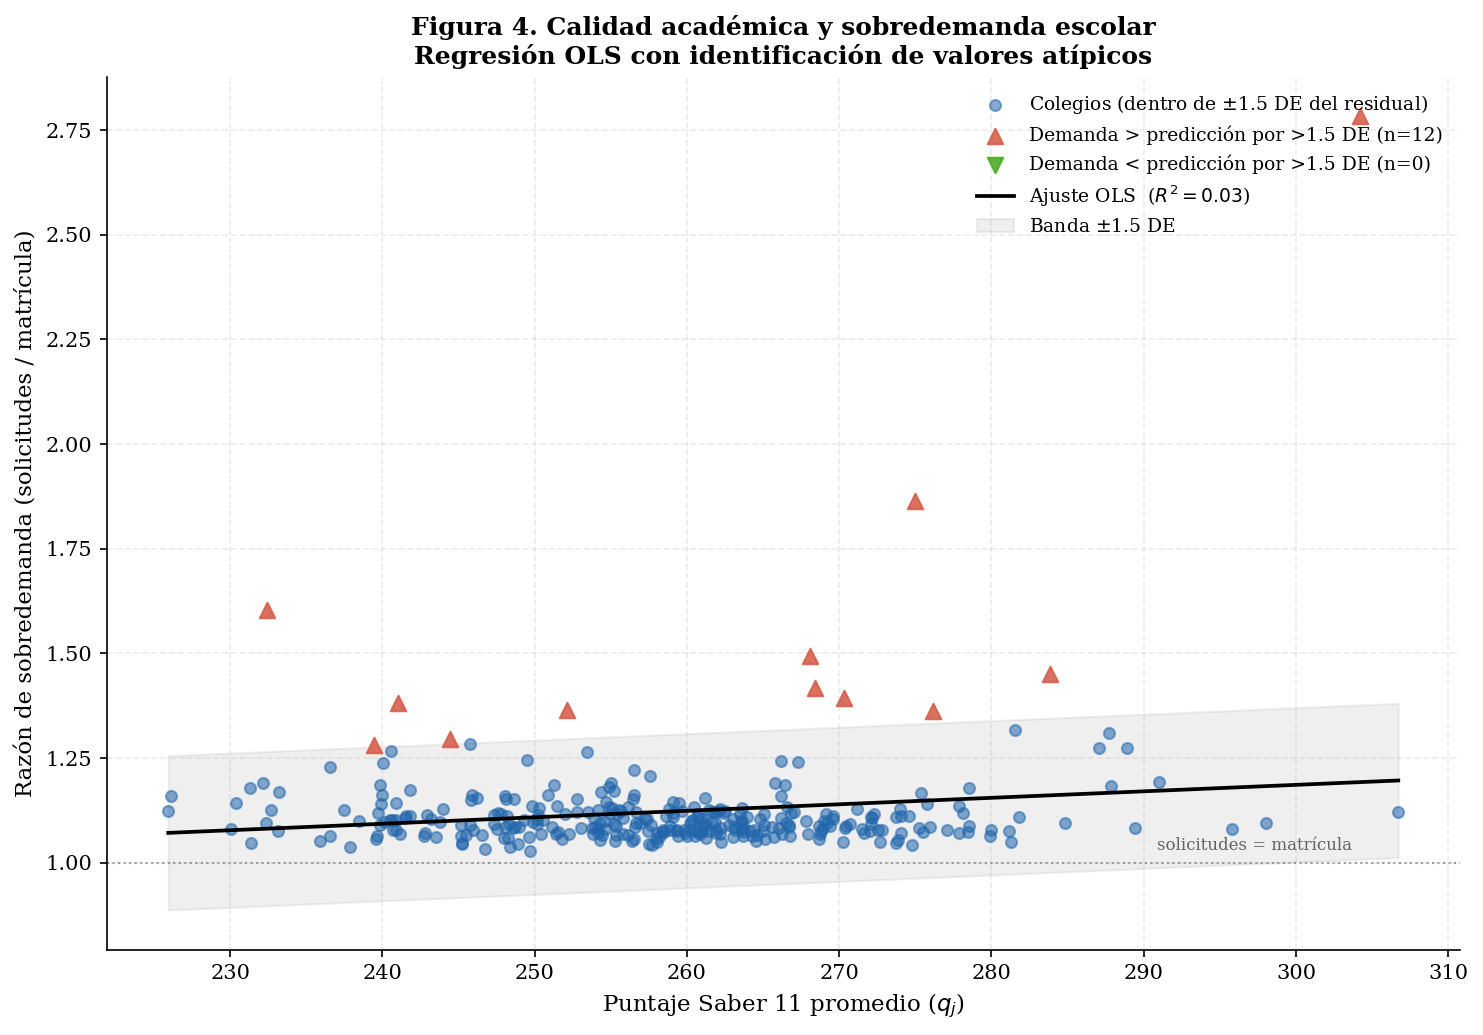

In [9]:
threshold = 1.5 * residuals.std()
mask_high = df_reg['residual'] >  threshold
mask_low  = df_reg['residual'] < -threshold
mask_norm = ~mask_high & ~mask_low

fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(df_reg.loc[mask_norm,'q_j'],  df_reg.loc[mask_norm,'sobre_demanda_j'],
           color=C1, alpha=0.55, s=28,
           label='Colegios (dentro de $\pm$1.5 DE del residual)', zorder=2)
ax.scatter(df_reg.loc[mask_high,'q_j'],  df_reg.loc[mask_high,'sobre_demanda_j'],
           color=C2, alpha=0.9, s=55, marker='^',
           label=f'Demanda > predicción por >1.5 DE (n={mask_high.sum()})', zorder=3)
ax.scatter(df_reg.loc[mask_low,'q_j'],   df_reg.loc[mask_low,'sobre_demanda_j'],
           color=C3, alpha=0.9, s=55, marker='v',
           label=f'Demanda < predicción por >1.5 DE (n={mask_low.sum()})', zorder=3)

x_line = np.linspace(x.min(), x.max(), 200)
y_line  = beta[0] + beta[1] * x_line
ax.plot(x_line, y_line, color='black', linewidth=1.8,
        label=f'Ajuste OLS  ($R^2 = {r2:.2f}$)', zorder=4)
ax.fill_between(x_line, y_line - threshold, y_line + threshold,
                color='gray', alpha=0.12, label='Banda $\pm$1.5 DE')

ax.axhline(1.0, color=GRAY, linestyle=':', linewidth=1, alpha=0.6)
ax.text(x.max() * 0.99, 1.02, 'solicitudes = matrícula',
        ha='right', va='bottom', fontsize=8, color=GRAY)

ax.set_xlabel('Puntaje Saber 11 promedio ($q_j$)')
ax.set_ylabel('Razón de sobredemanda (solicitudes / matrícula)')
ax.set_title('Figura 4. Calidad académica y sobredemanda escolar\n'
             'Regresión OLS con identificación de valores atípicos',
             fontweight='bold')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig(FIGURES / '05_scatter_calidad_vs_demanda.png', bbox_inches='tight', dpi=200)
plt.show()

In [10]:
cols_show = ['nombre_establecimiento','nombre_localidad','q_j','sobre_demanda_j','residual']
rename_map = {
    'nombre_establecimiento': 'Establecimiento',
    'nombre_localidad':       'Localidad',
    'q_j':                    'q_j',
    'sobre_demanda_j':        'Sobredemanda',
    'residual':               'Residual OLS',
}

print('Tabla 2. Colegios con demanda sustancialmente mayor a la predicción por calidad')
print('(Residual > 1.5 DE)\n')
print(
    df_reg.loc[mask_high, cols_show]
    .sort_values('residual', ascending=False)
    .round(3)
    .rename(columns=rename_map)
    .to_string(index=False)
)

print('\nTabla 3. Colegios con demanda sustancialmente menor a la predicción por calidad')
print('(Residual < -1.5 DE)\n')
print(
    df_reg.loc[mask_low, cols_show]
    .sort_values('residual')
    .round(3)
    .rename(columns=rename_map)
    .to_string(index=False)
)

Tabla 2. Colegios con demanda sustancialmente mayor a la predicción por calidad
(Residual > 1.5 DE)

                                Establecimiento      Localidad     q_j  Sobredemanda  Residual OLS
                     COLEGIO LA FELICIDAD (IED)       Fontibon 304.230         2.783         1.590
COLEGIO FILARMONICO JORGE MARIO BERGOGLIO (IED)           Suba 275.000         1.865         0.717
                     COLEGIO PANAMERICANO (IED)   Los Martires 232.433         1.605         0.523
                       COLEGIO EL ENSUEÑO (IED) Ciudad Bolivar 268.080         1.493         0.356
                       COLEGIO EMMA REYES (IED)        Kennedy 283.850         1.450         0.289
                           COLEGIO CHARRY (IED)       Engativa 240.993         1.382         0.287
                       COLEGIO BELLAVISTA (IED)        Kennedy 268.403         1.417         0.279
                           COLEGIO BILBAO (IED)           Suba 270.317         1.394         0.253
        

---
## 5. Controles Socioeconómicos y Correlaciones

Identificamos qué variables de control tienen mayor asociación con la sobredemanda.
Las correlaciones altas señalan potenciales confusores que deben incluirse en la
regresión estructural del modelo de matching.

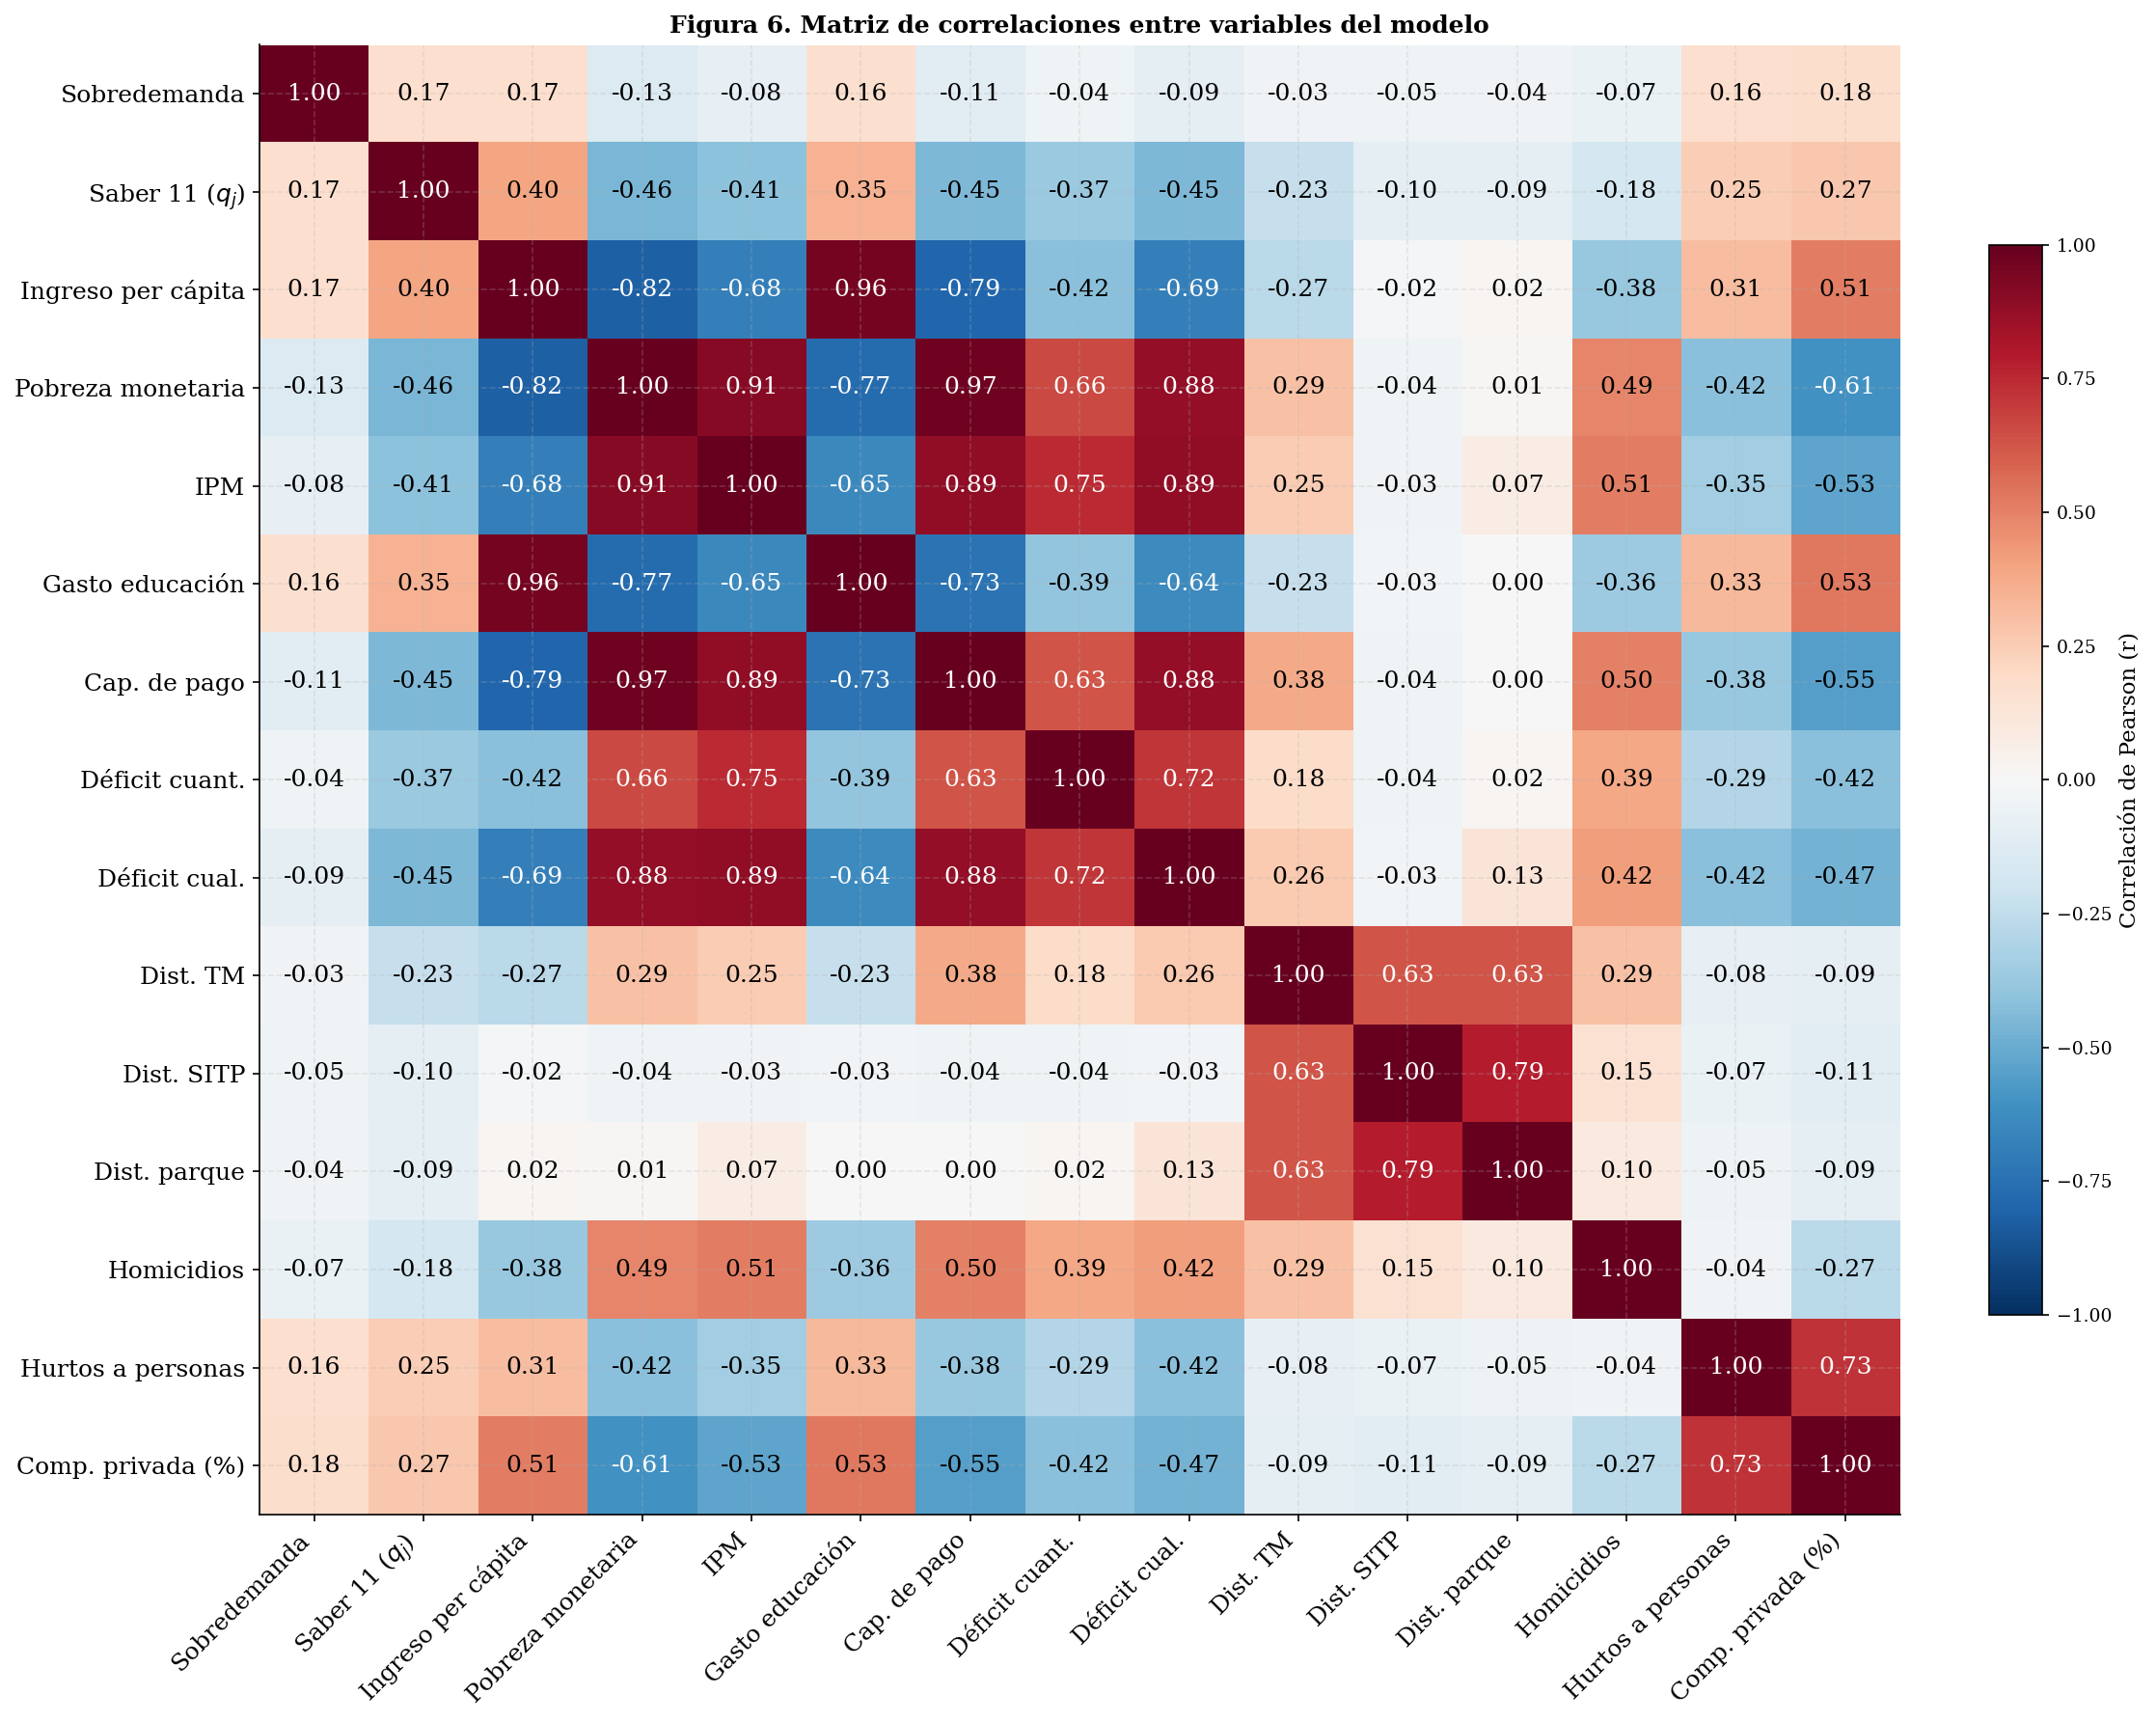

In [11]:
CORR_VARS = [
    'sobre_demanda_j', 'q_j',
    'ingreso_percapita_promedio', 'tasa_pobreza_monetaria', 'tasa_ipm',
    'gasto_educ_promedio', 'capacidad_pago_promedio',
    'tasa_deficit_cuantitativo', 'tasa_deficit_cualitativo',
    'dist_transmilenio_m', 'dist_sitp_m', 'dist_parque_m',
    'homicidios', 'hurto_personas',
    'pct_no_oficial',
]
CORR_VARS = [c for c in CORR_VARS if c in df.columns]

CORR_LABELS = {
    'sobre_demanda_j':            'Sobredemanda',
    'q_j':                        'Saber 11 ($q_j$)',
    'ingreso_percapita_promedio':  'Ingreso per cápita',
    'tasa_pobreza_monetaria':      'Pobreza monetaria',
    'tasa_ipm':                    'IPM',
    'gasto_educ_promedio':         'Gasto educación',
    'capacidad_pago_promedio':     'Cap. de pago',
    'tasa_deficit_cuantitativo':   'Déficit cuant.',
    'tasa_deficit_cualitativo':    'Déficit cual.',
    'dist_transmilenio_m':         'Dist. TM',
    'dist_sitp_m':                 'Dist. SITP',
    'dist_parque_m':               'Dist. parque',
    'homicidios':                  'Homicidios',
    'hurto_personas':              'Hurtos a personas',
    'pct_no_oficial':              'Comp. privada (%)',
}

corr_matrix = df[CORR_VARS].corr()
tick_labels = [CORR_LABELS.get(c, c) for c in CORR_VARS]

fig, ax = plt.subplots(figsize=(15, 12))
im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
cb = plt.colorbar(im, ax=ax, fraction=0.03, label='Correlación de Pearson (r)')
cb.ax.tick_params(labelsize=9)

ax.set_xticks(range(len(CORR_VARS)))
ax.set_yticks(range(len(CORR_VARS)))
ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=12)
ax.set_yticklabels(tick_labels, fontsize=12)

for i in range(len(CORR_VARS)):
    for j in range(len(CORR_VARS)):
        val = corr_matrix.values[i, j]
        color = 'white' if abs(val) > 0.55 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=12, color=color)

ax.set_title('Figura 6. Matriz de correlaciones entre variables del modelo', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / '06_matriz_correlaciones.png', bbox_inches='tight', dpi=200)
plt.show()

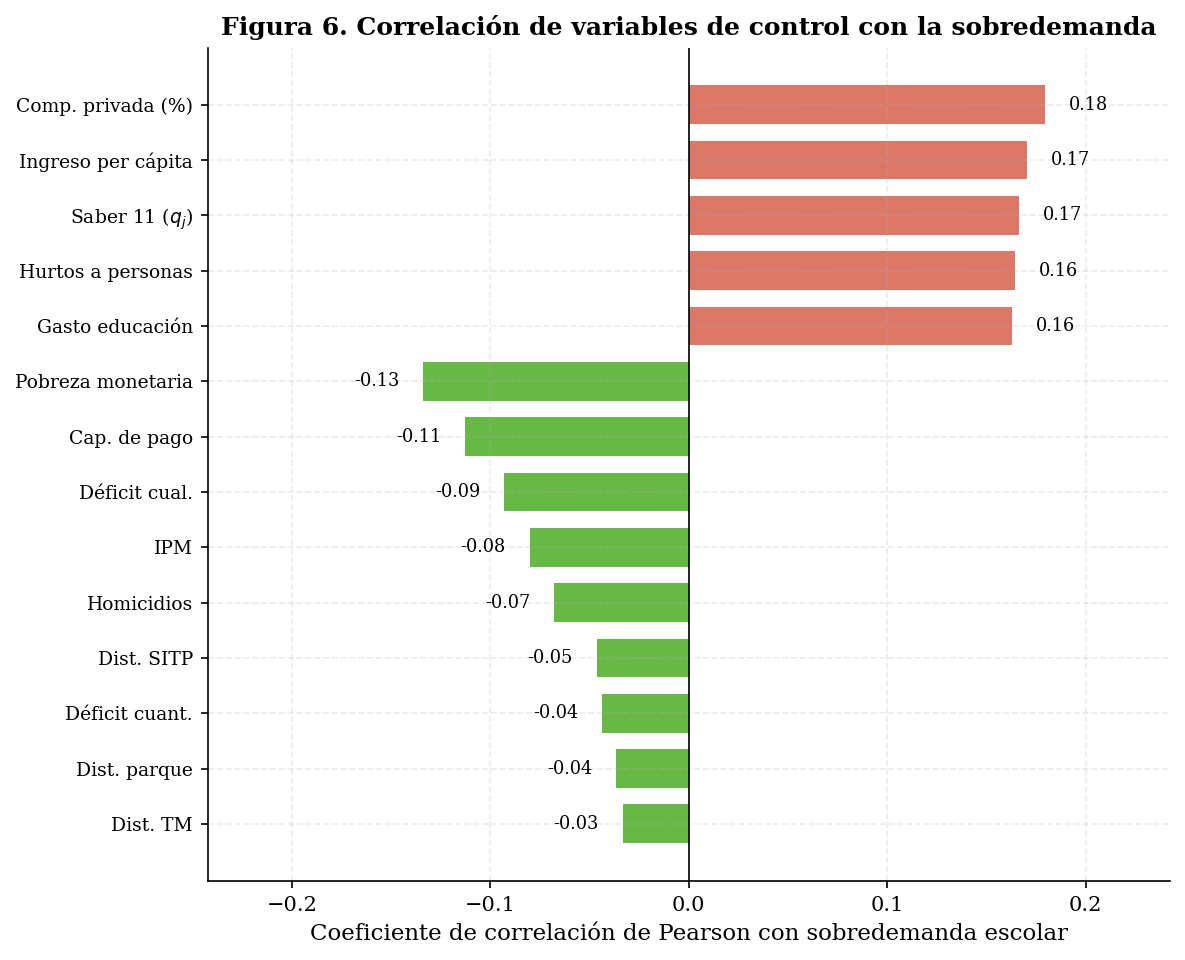

In [12]:
# Correlaciones con sobredemanda, ordenadas por magnitud absoluta
corr_sd = (
    corr_matrix['sobre_demanda_j']
    .drop('sobre_demanda_j')
    .sort_values(key=abs, ascending=True)
)

short_labels = [CORR_LABELS.get(c, c) for c in corr_sd.index]

fig, ax = plt.subplots(figsize=(8, 6.5))
colors = [C2 if v > 0 else C3 for v in corr_sd.values]
y_pos = range(len(corr_sd))

ax.barh(y_pos, corr_sd.values, color=colors, alpha=0.85, height=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels(short_labels, fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coeficiente de correlación de Pearson con sobredemanda escolar')
ax.set_title('Figura 6. Correlación de variables de control con la sobredemanda',
             fontweight='bold')

# Anotaciones de valor — desplazadas para no solapar el eje
x_lim = max(abs(corr_sd.values)) * 1.35
ax.set_xlim(-x_lim, x_lim)
for i, v in enumerate(corr_sd.values):
    pad = 0.012 if v >= 0 else -0.012
    ax.text(v + pad, i, f'{v:.2f}', va='center',
            ha='left' if v >= 0 else 'right', fontsize=8.5)

plt.tight_layout()
plt.savefig(FIGURES / '07_correlaciones_con_demanda.png', bbox_inches='tight')
plt.show()

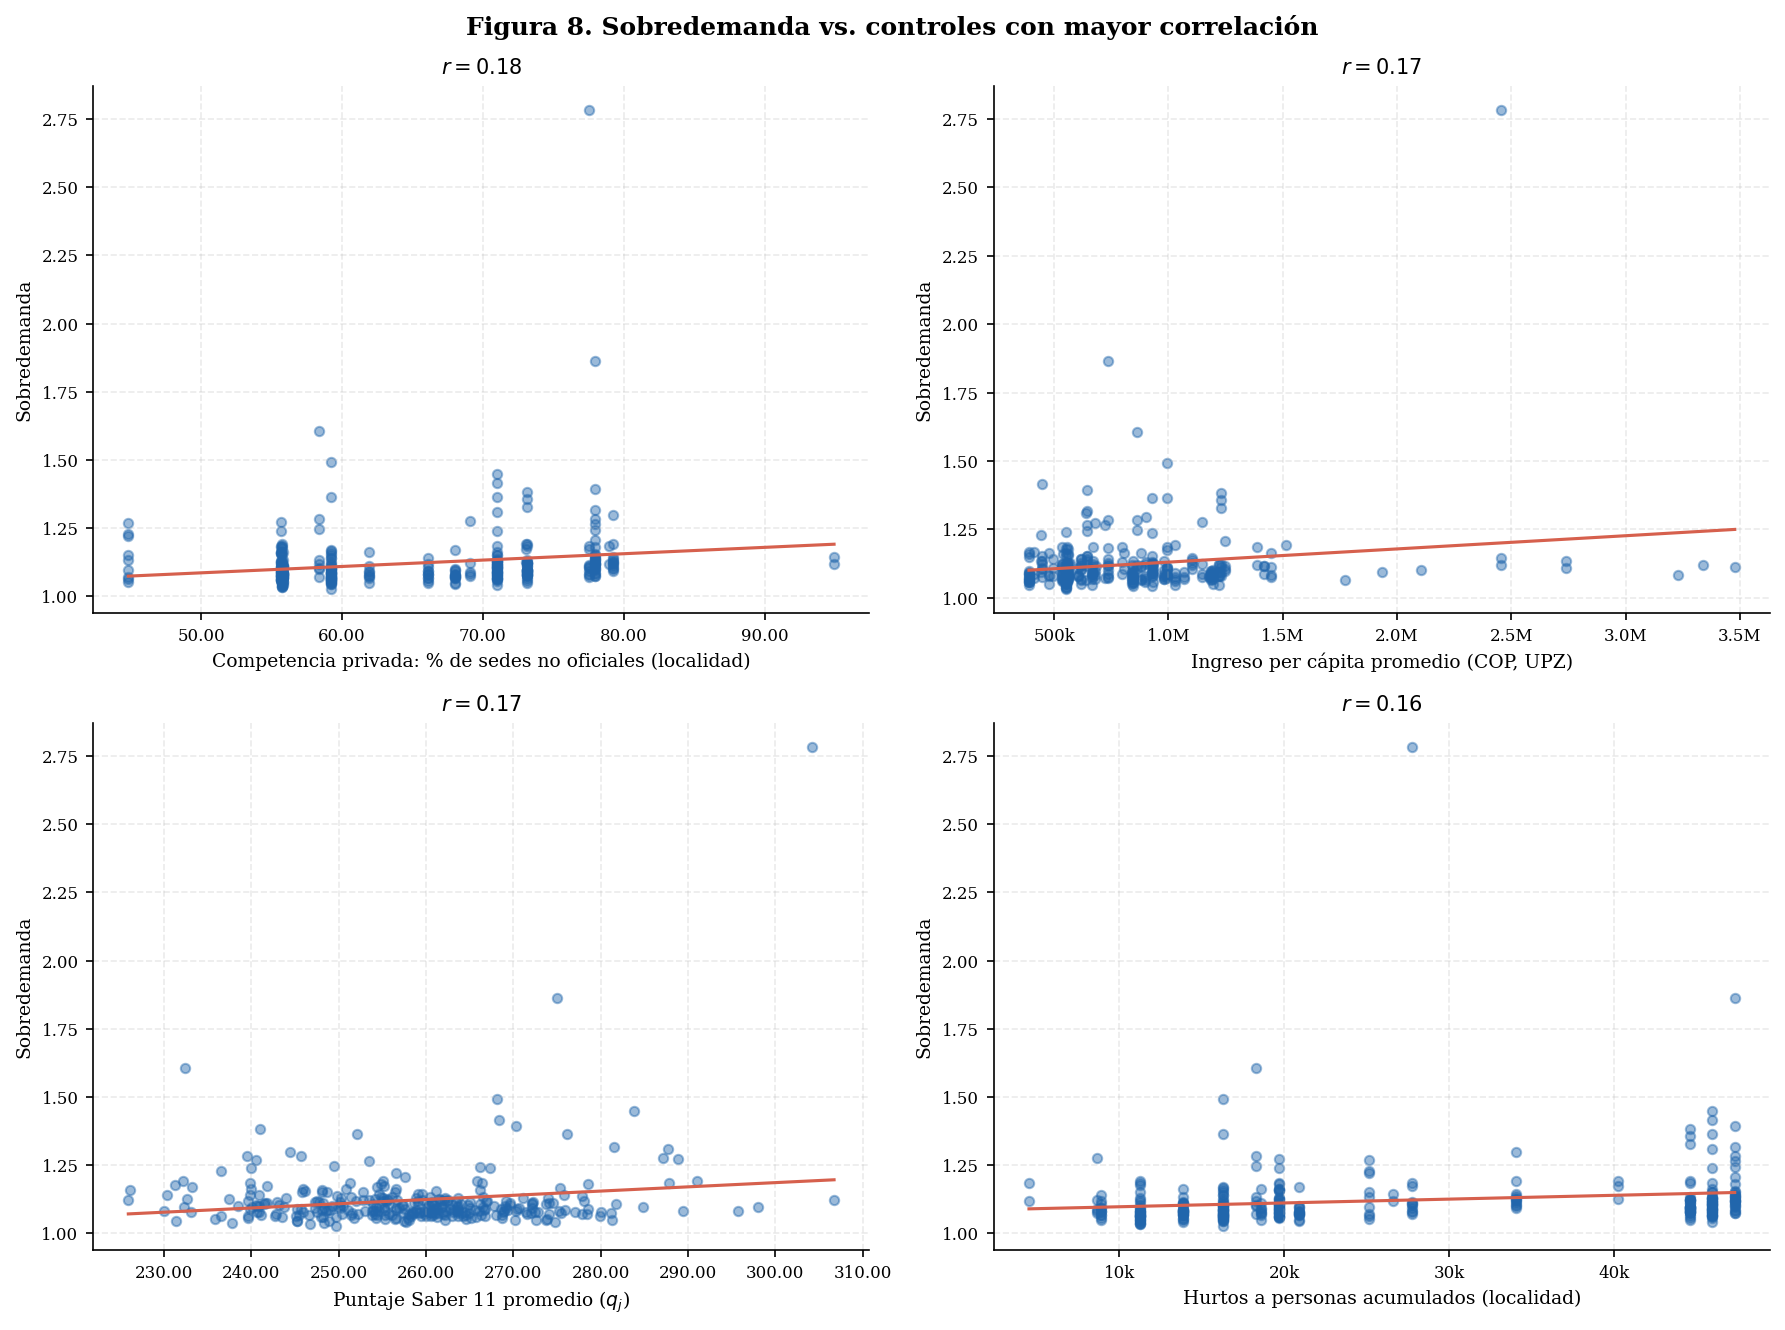

In [13]:
# Scatter: sobredemanda vs los 4 controles con mayor correlación absoluta
top4 = corr_sd.abs().sort_values(ascending=False).head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for ax, col in zip(axes, top4):
    data = df[['sobre_demanda_j', col]].dropna()
    xv, yv = data[col].values, data['sobre_demanda_j'].values
    ax.scatter(xv, yv, color=C1, alpha=0.45, s=20)

    Xm = np.column_stack([np.ones_like(xv), xv])
    b, *_ = np.linalg.lstsq(Xm, yv, rcond=None)
    xl = np.linspace(xv.min(), xv.max(), 200)
    ax.plot(xl, b[0] + b[1]*xl, color=C2, linewidth=1.5)
    r = np.corrcoef(xv, yv)[0, 1]

    ax.set_xlabel(LABELS.get(col, col), fontsize=9)
    ax.set_ylabel('Sobredemanda', fontsize=9)
    ax.set_title(f'$r = {r:.2f}$', fontsize=10)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{x/1e6:.1f}M' if abs(x) >= 1e6
        else (f'{x/1e3:.0f}k' if abs(x) >= 1000 else f'{x:.2f}')
    ))
    ax.tick_params(labelsize=8)

plt.suptitle('Figura 8. Sobredemanda vs. controles con mayor correlación',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / '08_scatter_controles.png', bbox_inches='tight')
plt.show()

---
## Resumen

In [14]:
print('=' * 65)
print('RESUMEN EDA')
print('=' * 65)
print(f'Muestra:                           {len(df):,} colegios')
print(f'Con puntaje Saber 11 (q_j):        {df["q_j"].notna().sum():,}')
print(f'Con datos de sobredemanda:          {df["sobre_demanda_j"].notna().sum():,}')
print()
print(f'q_j:  media={df["q_j"].mean():.1f}  DE={df["q_j"].std():.1f}  '
      f'rango=[{df["q_j"].min():.0f}, {df["q_j"].max():.0f}]')
print(f'Sobredemanda: media={df["sobre_demanda_j"].mean():.2f}  '
      f'DE={df["sobre_demanda_j"].std():.2f}')
print(f'Colegios sobredemandados (>1):      {(df["sobre_demanda_j"] > 1).sum()}')
print(f'Colegios subdemandados (<0.5):      {(df["sobre_demanda_j"] < 0.5).sum()}')
print()
print(f'R² OLS (q_j → sobredemanda):       {r2:.3f}')
print(f'Varianza no explicada:              {(1-r2)*100:.1f}%')
print()
print(f'Valores atípicos positivos:         {mask_high.sum()}')
print(f'Valores atípicos negativos:         {mask_low.sum()}')
print()
print('Figuras guardadas en reports/figures/eda/')
for p in sorted(FIGURES.glob('*.png')):
    print(f'  {p.name}')

RESUMEN EDA
Muestra:                           366 colegios
Con puntaje Saber 11 (q_j):        326
Con datos de sobredemanda:          354

q_j:  media=259.2  DE=15.1  rango=[226, 340]
Sobredemanda: media=1.12  DE=0.12
Colegios sobredemandados (>1):      354
Colegios subdemandados (<0.5):      0

R² OLS (q_j → sobredemanda):       0.028
Varianza no explicada:              97.2%

Valores atípicos positivos:         12
Valores atípicos negativos:         0

Figuras guardadas en reports/figures/eda/
  01_distribuciones_calidad_demanda.png
  02_distribuciones_controles.png
  03_mapa_calidad_demanda.png
  04_competencia_privada_localidad.png
  05_scatter_calidad_vs_demanda.png
  06_matriz_correlaciones.png
  07_correlaciones_con_demanda.png
  08_scatter_controles.png
